[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Harvard-CS1090/2026-CS1090A-public/blob/sec04-2026/sec04/cs1090a_sec04_student.ipynb)

> **On Colab, do `File → Save a copy in Drive` before you start.** This notebook opens from GitHub, so you can type in it and run it right away — but nothing is being saved anywhere. Close the tab and the work is gone. Saving a copy first gives you one that persists in your own Drive.

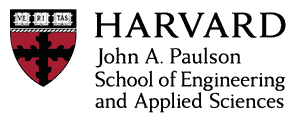

# CS1090A Introduction to Data Science

### Section 4 — Cross-validation and Model Selection


In [ ]:
# Provided — setup. On Colab this fetches the data files this notebook needs.
# Everywhere else it does nothing except confirm they are already here.
#
# Generated at publish time; see utils/inject_colab_bootstrap.py. Editing this cell
# in the public repo is wasted work -- the next publish overwrites it.
import os
import shutil
import subprocess
import sys

_REPO    = "https://github.com/Harvard-CS1090/2026-CS1090A-public"
_REF     = "sec04-2026"
_SECTION = "sec04"

_DIRNAME = _REPO.rstrip("/").split("/")[-1].removesuffix(".git")

if os.path.isdir("data"):
    print(f"data/ is present -- nothing to fetch.")
elif "google.colab" not in sys.modules:
    raise RuntimeError(
        "This notebook reads its inputs from a data/ folder, which is not here.\n"
        "It does not fetch them from the live web -- that is deliberate, and Part 1\n"
        "explains why.\n\n"
        "Fix: get the whole folder, not just the notebook --\n"
        f"    git clone --branch {_REF} {_REPO}\n"
        f"    cd {_DIRNAME}/{_SECTION}\n"
        "    jupyter lab\n\n"
        "Then open this notebook from in there. (On Colab, this cell fetches it for you.)"
    )
else:
    print("Colab detected, no data/ -- fetching it once...")
    _tmp = "/content/_cs1090a_materials"
    if not os.path.isdir(_tmp):
        _r = subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", _REF, _REPO, _tmp],
            capture_output=True, text=True,
        )
        if _r.returncode != 0:
            raise RuntimeError(
                f"Could not download the data files from {_REPO} (ref {_REF}).\n\n"
                f"git said: {_r.stderr.strip().splitlines()[-1] if _r.stderr.strip() else 'no output'}\n\n"
                "This is not something you did wrong. Post on Ed with this message and\n"
                "a TF will sort it out; meanwhile the section notebook will not run here."
            )
    _dir = os.path.join(_tmp, _SECTION)
    _src = os.path.join(_dir, "data")
    if not os.path.isdir(_src):
        raise RuntimeError(
            f"Cloned {_REPO} at {_REF} but found no {_SECTION}/data in it.\n"
            "The published bundle is incomplete -- please report this on Ed."
        )
    shutil.copytree(_src, "data")

    # Sibling modules too, not just data/. Section 1 does `from section_helpers import
    # Recorded`; fetching data/ alone leaves that import failing three cells later,
    # which reads as "the notebook is broken" rather than "setup was incomplete".
    _mods = [f for f in os.listdir(_dir) if f.endswith(".py")]
    for _m in _mods:
        shutil.copy(os.path.join(_dir, _m), _m)

    print(f"data/ ready ({len(os.listdir('data'))} entries)"
          + (f", plus {', '.join(sorted(_mods))}." if _mods else "."))


<div style="background:#E8F1FF; border-left:6px solid #2563EB; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🎯 Objectives — what you should be able to do by the end</div>
<div>
<ul>
<li>explain why a single train/validation split can give an unreliable estimate of performance; and</li>
<li>implement \(k\)-fold cross-validation and use it to choose model complexity.</li>
</ul>
</div>
</div>

**Coloured boxes:** 🤔 commit to a prediction before running the code · 🏋️ write code (look for `# your code here`) · 💬 stop running cells and discuss · ⭐ the point of the exercise · 💡 connect it to your own work · 🧠 what to carry out of the room · 🔍 an appendix item to work through on your own afterwards.

**The data.** Concrete gets its strength from its recipe: how much cement, water, and additives
go into the mix. The only way to know what a mix can take is to pour a cylinder, let it cure,
and crush it. Our data is a lab's record of doing that for several hundred mixes.

<div style="background:#FFF7CC; border-left:6px solid #D97706; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🤔 Predict — before anything runs</div>
<div>
We will fit polynomials of degree 1 through 6 on one set of rows and score them on another.
<ul>
<li>Will the held-out \(R^2\) keep improving as the degree goes up?</li>
<li>Would the same degree win from a different random split?</li>
</ul>
Write both down. You will come back to them at the end.
</div>
</div>

## Part 1. The candidate models

We use a family of models with one complexity setting, the polynomial degree, so that
"choosing a model" means choosing one number.

### Load the data

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# some NEW imports here!
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")

In [ ]:
df = pd.read_csv("data/concrete_28day.csv")
df.head(3)

One row per mix, all crushed at 28 days of curing. `strength` (MPa) is the response; the other
seven columns are the recipe in kg/m³.

### Three ingredients

We model strength from three of the seven. Appendix A2 puts the other four back.

- **Cement** is the binder: more cement, more strength.
- **Water** is what makes cement react, but any water beyond that leaves voids when it evaporates, so more water means less strength. The water-to-cement *ratio* is the best-known lever on concrete strength.
- **Superplasticizer** makes a stiff mix flow, so a plant can use less water and still pour it.

In [ ]:
# Each ingredient on its own, with the mean strength in each of 8 bins overlaid.
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, feature in zip(axes, ["cement", "water", "superplasticizer"]):
    ax.scatter(df[feature], df["strength"], s=12, alpha=0.25)
    bins = pd.qcut(df[feature], 8, duplicates="drop")
    means = df.groupby(bins, observed=True).agg(x=(feature, "mean"), y=("strength", "mean"))
    ax.plot(means.x, means.y, marker="o", color="tab:red", linewidth=2, label="binned mean")
    ax.set(xlabel=f"{feature} (kg/m$^3$)", ylabel="strength (MPa)",
           title=f"{feature}  (r = {df[feature].corr(df['strength']):+.2f})")
    ax.legend()
plt.show()

<div style="background:#F3E8FF; border-left:6px solid #7E22CE; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">⭐ Insight — why we expect some curvature</div>
<div>
Strength tracks the water-to-cement <em>ratio</em>, and no weighted sum of these columns can
express a ratio. A curved surface can approximate one, so expect degree 2 to beat degree 1.
Cross-validation only chooses among the models you wrote down; domain knowledge puts the
right ones on that list.
</div>
</div>

### Train, validation, and test split

Two splits. The **test** rows are sealed until Part 5. Everything else is the pool we develop
the model on, `X_dev`, and for Part 1 we carve a **validation** set out of it.

In [ ]:
model_features = ["cement", "water", "superplasticizer"]

X = df[model_features]
y = df["strength"]
X.shape, y.shape

In [ ]:
# X_test is sealed until Part 5. X_train / X_val are carved out of X_dev, the non-test pool.
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, shuffle=True, random_state=209
)
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.20, shuffle=True, random_state=209
)

print(f"fit {len(X_train)}   validate {len(X_val)}   (test {len(X_test)}, sealed)")

### Polynomial features

A **polynomial model** is still a **linear** model, linear in its coefficients. We hand it
extra columns that are powers and products of the originals:

$$\text{strength} \approx \beta_0 + \beta_1\,\text{cement} + \beta_2\,\text{cement}^2
+ \beta_3\,\text{water} + \beta_4\,(\text{cement}\times\text{water}) + \ldots$$

`PolynomialFeatures(degree)` builds those columns. Turning the degree up adds more of them.

<div style="background:#FFF7CC; border-left:6px solid #D97706; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🤔 How many columns in the design matrix?</div>
<div>
<code style="background:rgba(0,0,0,0.06); color:#1F2937;">PolynomialFeatures(degree=2)</code> is applied to our <strong>3</strong> predictors.
How many columns come out (including the intercept column of ones)?

<ol style="list-style:none; padding-left:1.2em;">
<li><strong>A.</strong> 6</li>
<li><strong>B.</strong> 9</li>
<li><strong>C.</strong> 10</li>
<li><strong>D.</strong> 16</li>
</ol>
</div>
</div>

In [ ]:
# The column-maker for degree 2
degree = 2
poly = PolynomialFeatures(degree)

In [ ]:
X_train_poly = poly.fit_transform(X_train)
X_train_poly.shape

In [ ]:
# The new columns are on very different scales
X_train_poly.mean(axis=0), X_train_poly.std(axis=0)

### Scaling

`StandardScaler` gives every column mean 0 and standard deviation 1. Appendix A3 shows what
goes wrong at high degree without it.

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_poly_scale = scaler.fit_transform(X_train_poly)
X_train_poly_scale.shape

In [ ]:
X_train_poly_scale.mean(axis=0), X_train_poly_scale.std(axis=0)

### Fit and score

In [ ]:
# Ordinary least squares on the scaled polynomial columns
poly_reg = LinearRegression().fit(X_train_poly_scale, y_train)
poly_reg.intercept_, poly_reg.coef_

In [ ]:
# Most sklearn models have a .score method. For LinearRegression it is R^2.
poly_reg.score(X_train_poly_scale, y_train)

In [ ]:
# The model expects the transformed columns. To score on validation rows we would have to
# redo both transforms by hand, every time. There must be a better way: pipelines.
try:
    poly_reg.score(X_val, y_val)
except Exception as e:
    print(e)

### Pipelines

A `Pipeline` chains the transforms and the model into one object. `fit` runs each step's
`fit_transform` in turn and then fits the model; `predict` and `score` run each step's
`transform`, so new rows get exactly the same treatment without any extra code.

In [ ]:
def polynomial_model(degree):
    # The scaler sits inside the pipeline, between the expansion and the regression (appendix A3 says why).
    return make_pipeline(PolynomialFeatures(degree), StandardScaler(), LinearRegression())

In [ ]:
poly_pipe = polynomial_model(degree)
poly_pipe

In [ ]:
poly_pipe.fit(X_train, y_train)

In [ ]:
# The pipeline itself has no coefficients...
try:
    poly_pipe.coef_
except Exception as e:
    print(e)

In [ ]:
# ...its last step does
poly_pipe['linearregression']

In [ ]:
poly_pipe['linearregression'].coef_

In [ ]:
# Scoring on new rows now just works
poly_pipe.score(X_val, y_val)

<div style="background:#FFF7CC; border-left:6px solid #D97706; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🤔 Predict — can more columns fit the training rows worse?</div>
<div>
A degree-3 model is handed every column the degree-2 model had, plus more.
<ul>
<li>Can it score <em>worse</em> than degree 2 on the rows it was fitted to?</li>
<li>What does your answer say the <code style="background:rgba(0,0,0,0.06); color:#1F2937;">train_r2</code> column has to look like?</li>
</ul>
</div>
</div>

<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise 1: pick a degree the usual way (4 min)</div>
<div>
Complete <code style="background:rgba(0,0,0,0.06); color:#1F2937;">evaluate</code> so it fits one
degree on the fit rows and scores it on both the fit rows and the validation rows. Then run it
for every degree from 1 to 6.
</div>
</div>

In [ ]:
def evaluate(degree):
    # Fit one degree on X_train and score it on X_train and on X_val. (Using globals inside a
    # function is usually a bad idea; here it keeps the call short.)
    # your code here
    model = ...          # fit on the TRAIN set
    
    return {
        "degree": degree,
        "train_r2": ...,      # scored on data it has seen
        "val_r2": ...,        # scored on the validation rows it has not
    }


In [ ]:
evaluate(2)

In [ ]:
# One row per degree
degrees = range(1, 7)
# your code here
single_split = pd.DataFrame([... for d in degrees])   # one evaluate() call per degree

display(single_split.round(3))

<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 1: how much of this table do you believe?</div>
<div>
<ul>
<li>Does <code style="background:rgba(0,0,0,0.06); color:#1F2937;">train_r2</code> obey the theorem?</li>
<li>Which degree does <code style="background:rgba(0,0,0,0.06); color:#1F2937;">val_r2</code> pick, and would another random draw pick the same one?</li>
</ul>
</div>
</div>

## Part 2. How much the score depends on the split

<div style="background:#FFF7CC; border-left:6px solid #D97706; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🤔 Predict — the same selection on 200 different splits</div>
<div>
The next cell repeats Part 1's selection 200 times, changing only which rows are held back.
Commit to two numbers:
<ol>
<li>How many <strong>different</strong> degrees will win at least once?</li>
<li>Holding the degree at 2, how wide will its held-out \(R^2\) range?</li>
</ol>
</div>
</div>

### 200 random splits

In [ ]:
# Repeat Part 1's selection on 200 random splits of the non-test pool. X_test plays no part.
chosen_degrees, fixed_degree_scores = [], []

for seed in range(200):
    X_fit, X_hold, y_fit, y_hold = train_test_split(
        X_dev, y_dev, test_size=0.20, shuffle=True, random_state=seed
    )
    scores = [
        r2_score(y_hold, polynomial_model(d).fit(X_fit, y_fit).predict(X_hold)) for d in degrees
    ]
    chosen_degrees.append(list(degrees)[int(np.argmax(scores))])
    fixed_degree_scores.append(scores[1])            # degree 2, held constant throughout

chosen_degrees = np.array(chosen_degrees)
fixed_degree_scores = np.array(fixed_degree_scores)

print("distinct 'best degrees' found:", sorted(set(chosen_degrees.tolist())))
print(f"degree 2 held-out R2 ranged from {fixed_degree_scores.min():.3f} "
      f"to {fixed_degree_scores.max():.3f}")

### The two histograms

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
axes[0].hist(chosen_degrees, bins=np.arange(0.5, 7.5), edgecolor="white")
axes[0].set(xlabel="degree chosen as 'best'", ylabel="number of splits",
            title="Which degree wins depends on the split")
axes[1].hist(fixed_degree_scores, bins=20, edgecolor="white")
axes[1].set(xlabel="held-out $R^2$ at a fixed degree 2", ylabel="number of splits",
            title="Even at one fixed model, the score moves")
plt.show()

<div style="background:#F3E8FF; border-left:6px solid #7E22CE; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">⭐ Insight — a single split is one noisy sample</div>
<div>
Several degrees win at least once, and at one fixed model the held-out \(R^2\) moves
further from split to split than any two models differ. If changing the split moves your
score more than changing the model does, the score is mostly measuring the split. That is
what cross-validation removes.
</div>
</div>

## Part 3. k-fold cross-validation by hand

$k$-fold cross-validation splits the training pool into $k$ blocks. Each block takes one turn
as the validation set while the other $k-1$ blocks train the model, so every row is predicted
exactly once, by a model that never saw it. The result is an average over $k$ splits instead
of a gamble on one, and the test set stays sealed.

Shuffling rows into random folds assumes the rows are interchangeable. Here they are, because
each row is a different mix. Repeated measurements of one unit, or data in time order, would
need `GroupKFold` or `TimeSeriesSplit` instead.

### What `KFold.split` yields

In [ ]:
kfold = KFold(n_splits=5, shuffle=True, random_state=209)

In [ ]:
# The first of the five (fit rows, validation rows) pairs of row positions
fit_index, validate_index = next(kfold.split(X_dev))
len(fit_index), len(validate_index), validate_index[:10]

### The loop, written out

In [ ]:
def manual_cv_r2(degree, X_data, y_data):
    # Cross-validated R2, one fold at a time
    fold_scores = []

    for fit_index, validate_index in kfold.split(X_data):
        X_fit, X_validate = X_data.iloc[fit_index], X_data.iloc[validate_index]
        y_fit, y_validate = y_data.iloc[fit_index], y_data.iloc[validate_index]

        model = polynomial_model(degree).fit(X_fit, y_fit)
        fold_scores.append(r2_score(y_validate, model.predict(X_validate)))

    return np.array(fold_scores)

In [ ]:
mine = manual_cv_r2(2, X_dev, y_dev)
print("by hand     :", mine.round(4), "-> mean", mine.mean().round(4))

### The same thing with `cross_val_score`

In [ ]:
theirs = cross_val_score(polynomial_model(2), X_dev, y_dev, cv=kfold, scoring="r2")
print("scikit-learn:", theirs.round(4), "-> mean", theirs.mean().round(4))

assert np.allclose(mine, theirs), "the two should agree exactly"
print("\nThey match.")

<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 2: what did the folds cost us?</div>
<div>
<ul>
<li>Each fold trains on 80% of the pool. Optimistic or pessimistic?</li>
<li>What does the <em>spread</em> of the five scores add to the mean?</li>
</ul>
</div>
</div>

## Part 4. Choose the degree with cross-validation

<div style="background:#FFF7CC; border-left:6px solid #D97706; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🤔 Predict — will it agree?</div>
<div>
Part 1's single split picked a degree. Will 5-fold cross-validation pick the same one, a
simpler one, or a more complex one?
</div>
</div>

<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise 2: scan the degrees (6 min)</div>
<div>
For each degree, get the five fold scores from <code style="background:rgba(0,0,0,0.06); color:#1F2937;">cross_val_score</code> and record their mean
and their standard error, <code style="background:rgba(0,0,0,0.06); color:#1F2937;">scores.std(ddof=1) / np.sqrt(k)</code> (the sample standard
deviation; NumPy's default divides by \(k\) rather than \(k-1\)). Then apply the
one-standard-error rule in the cell that follows.
</div>
</div>

### Cross-validated score at every degree

In [ ]:
rows = []
for degree in degrees:
    # your code here
    scores = ...                    # the k fold scores for this degree
    rows.append({
        "degree": degree,
        "cv_r2": ...,               # the mean of those k scores
        "std_error": ...,           # sample sd (ddof=1) / sqrt(k)
    })

cv_table = pd.DataFrame(rows)

In [ ]:
cv_table.round(3)

### The one-standard-error rule

Find the best mean score, subtract one standard error to get a threshold, and take the
**simplest** degree whose mean still clears it. Two models the folds cannot tell apart are
settled on simplicity.

In [ ]:
# your code here
best_row = cv_table.loc[...]                 # the row with the highest cv_r2
best_degree = int(best_row.degree)
threshold = ...                              # one standard error below that best score
simplest_within_one_se = ...                 # smallest degree whose cv_r2 clears it

print(f"best CV score at degree {best_degree}")
print(f"one SE below it: {threshold:.4f}")
print(f"simplest degree still above that line: {simplest_within_one_se}")

### The picture

In [ ]:
plt.figure(figsize=(9, 5))
plt.errorbar(cv_table.degree, cv_table.cv_r2, yerr=cv_table.std_error,
             marker="o", capsize=4, linewidth=2)
plt.axhline(threshold, color="grey", linestyle=":",
            label=f"one SE below the best ({threshold:.3f})")
plt.axvline(best_degree, color="black", linestyle="--",
            label=f"best CV: degree {best_degree}")
plt.axvline(simplest_within_one_se, color="tab:green", linestyle="-.",
            label=f"one-SE rule: degree {simplest_within_one_se}")
plt.xlabel("polynomial degree"); plt.ylabel("cross-validated $R^2$")

# High degrees fall far below the axis. Clip the y-axis and annotate the off-scale values
# so an empty patch of plot is not mistaken for a missing value.
plt.ylim(-0.4, 0.6)
off_scale = cv_table.loc[cv_table.cv_r2 < -0.4]
for _, row in off_scale.iterrows():
    plt.annotate(f"{row.cv_r2:.0f}\n\u2193", (row.degree, -0.34),
                 ha="center", va="top", fontsize=9, color="tab:red")
plt.legend(loc="lower left")
plt.show()

<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 3: read the error bars, not only the peak</div>
<div>
<ul>
<li>The single split and cross-validation disagree. Which do you believe?</li>
<li>At degrees 2 and 3, which moved first, the mean or the error bar?</li>
<li>Did the one-standard-error rule move you off the peak?</li>
</ul>
</div>
</div>

## Part 5. Open the test set

Nothing so far has used `X_test`: Part 1 scored on its own validation rows, Part 2 re-split
the training pool, and Parts 3 and 4 cross-validated it. Choosing a degree is a choice, so
the rows used to choose cannot also be the rows used to report. Look at the test set once.

### Fit the chosen degree on every training row

In [ ]:
final_model = polynomial_model(simplest_within_one_se).fit(X_dev, y_dev)
final_model

### Score it once

In [ ]:
test_r2 = r2_score(y_test, final_model.predict(X_test))
test_rmse = np.sqrt(mean_squared_error(y_test, final_model.predict(X_test)))
cv_estimate = cv_table.loc[cv_table.degree == simplest_within_one_se, "cv_r2"].iloc[0]

print(f"chosen degree (one-SE rule)  : {simplest_within_one_se}")
print(f"cross-validated R2 (expected): {cv_estimate:.3f}")
print(f"test R2 (actual, seen once)  : {test_r2:.3f}")
print(f"test RMSE                    : {test_rmse:.1f} MPa")
print(f"\nfor scale, specimen strength averages {y.mean():.1f} MPa")

<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 4: the test score is not the CV estimate</div>
<div>
<ul>
<li>Is the gap news about the model, or about the test set? See Part 2's right-hand histogram.</li>
<li>Which number goes in the report, and what is the other one for?</li>
<li>If we tried another degree now, what would we lose?</li>
</ul>
</div>
</div>

<div style="background:#E6F7FF; border-left:6px solid #0891B2; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💡 Reflect — one quiet minute</div>
<div>
Return to the two predictions you wrote at the start.
<ol>
<li>Which one were you further off on?</li>
<li>What is one thing you will now do differently in your own modelling?</li>
</ol>
Then compare with a partner.
</div>
</div>

<div style="background:#F3F4F6; border-left:6px solid #4B5563; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🧠 Takeaways — three things to remember</div>
<div>
<ol>
<li><strong>A single split gives one noisy sample of how well the model does.</strong> Which degree wins changes with the rows held back.</li>
<li><strong>Cross-validation averages several splits and shows how much the folds disagreed.</strong> Within one standard error, take the simpler model.</li>
<li><strong>Anything fitted to data, the scaler included, goes inside the <code style="background:rgba(0,0,0,0.06); color:#1F2937;">Pipeline</code>.</strong> Every fold then refits it. Otherwise cross-validation will certify pure noise (A6).</li>
</ol>

<strong>Exit ticket:</strong> a colleague reports a cross-validated \(R^2\) of 0.62 and a test \(R^2\) of 0.28. Give two explanations, one innocent and one not.
</div>
</div>

---

## Appendix — six things to try later

**Nothing below is expected during section or assessed.** Each item is a 🔍 Explore box:
the code below it is provided and runs as-is, and the work is reading the output and
answering the questions. Every item has a worked answer in the solutions notebook.

- **A1** — does the number of folds change the answer?
- **A2** — what were the four ingredients we left out worth?
- **A3** — why the scaler inside the pipeline is not cosmetic.
- **A4** — preparing numeric and categorical columns differently, in one pipeline.
- **A5** — reading a residual plot.
- **A6** — how cross-validation can report a score that is far too good.

### A1. How many folds?

<div style="background:#E8F6F3; border-left:6px solid #0F766E; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🔍 Explore — A1</div>
<div>
The cell below re-runs the Part 4 scan at \(k=2\), \(5\), \(10\) and leave-one-out.
Leave-one-out uses <code style="background:rgba(0,0,0,0.06); color:#1F2937;">scoring="neg_mean_squared_error"</code> because \(R^2\) needs the
variance of the held-out values and one value has none (less negative is better).
<ol>
<li>Compare the degree-6 number across \(k=2\), \(5\) and \(10\). How much should you trust any of them?</li>
<li>Do all four schemes pick the same degree? If not, which degrees do they disagree between?</li>
<li>Leave-one-out trains on the most data per fold. Why is it still not the automatic choice?</li>
</ol>
</div>
</div>

In [ ]:
# The Part 4 scan at four fold counts, with the number of fits each one costs.
import math
import time


def rounded_time(seconds):
    # Rounded to a power of ten, so rebuilding this notebook does not record a new timing.
    return "<1s" if seconds < 1 else f"~{10 ** round(math.log10(seconds))}s"


fold_counts = {
    "k=2": (KFold(n_splits=2, shuffle=True, random_state=209), "r2"),
    "k=5": (KFold(n_splits=5, shuffle=True, random_state=209), "r2"),
    "k=10": (KFold(n_splits=10, shuffle=True, random_state=209), "r2"),
    # R2 needs two points for a denominator, so leave-one-out has to change metric.
    "leave-one-out": (KFold(n_splits=len(X_dev)), "neg_mean_squared_error"),
}

for label, (splitter, scoring) in fold_counts.items():
    started = time.perf_counter()
    means = []
    for degree in degrees:
        scores = cross_val_score(polynomial_model(degree), X_dev, y_dev,
                                 cv=splitter, scoring=scoring)
        means.append(scores.mean())
    elapsed = time.perf_counter() - started
    n_fits = len(list(degrees)) * splitter.get_n_splits(X_dev)
    best = int(np.argmax(means)) + 1
    print(f"{label:>14s} ({scoring:>25s}, {n_fits:>5d} fits, {rounded_time(elapsed):>6s})  "
          f"best degree {best}")
    print(f"{'':>14s}  " + "  ".join(f"d{d}:{m:>9.3f}" for d, m in zip(degrees, means)))

### A2. What was the rest of the recipe worth?

<div style="background:#E8F6F3; border-left:6px solid #0F766E; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🔍 Explore — A2</div>
<div>
The cell below rebuilds <code style="background:rgba(0,0,0,0.06); color:#1F2937;">X</code> from every column except <code style="background:rgba(0,0,0,0.06); color:#1F2937;">strength</code>, re-splits with the
same <code style="background:rgba(0,0,0,0.06); color:#1F2937;">random_state=209</code>, and re-runs the Part 4 scan. <code style="background:rgba(0,0,0,0.06); color:#1F2937;">math.comb(p + d, d)</code> gives
the column count in the second column of the table.
<ol>
<li>How much does the cross-validated \(R^2\) improve, and at which degree?</li>
<li>At what degree does the design matrix outgrow the training rows, and what has CV already done by then?</li>
<li>Does the one-standard-error rule still choose the same degree?</li>
</ol>
</div>
</div>

In [ ]:
# The Part 4 scan on all seven ingredients, against the three-ingredient numbers.
from math import comb

all_features = [c for c in df.columns if c != "strength"]
X_all = df[all_features]
X_all_dev, X_all_test, y_all_dev, y_all_test = train_test_split(
    X_all, y, test_size=0.20, shuffle=True, random_state=209
)

print(f"{len(all_features)} predictors instead of {len(model_features)}\n")
print(f"{'degree':>7}{'columns':>9}{'CV R2 (3 ingr)':>18}{'CV R2 (7 ingr)':>18}")
wide_rows = []
for degree in [1, 2, 3, 4, 5]:
    columns = comb(len(all_features) + degree, degree)
    narrow = cv_table.loc[cv_table.degree == degree, "cv_r2"].iloc[0]
    if degree <= 3:              # beyond this the fit is numerically meaningless anyway (A3)
        scores = cross_val_score(polynomial_model(degree), X_all_dev, y_all_dev,
                                 cv=kfold, scoring="r2")
        wide_rows.append({"degree": degree, "cv_r2": scores.mean(),
                          "std_error": scores.std(ddof=1) / np.sqrt(len(scores))})
        shown = f"{scores.mean():>18.3f}"
    else:
        shown = f"{'(not fitted)':>18}"
    print(f"{degree:>7}{columns:>9}{narrow:>18.3f}" + shown)

print(f"\n...against {len(X_all_dev)} training rows.")

wide_table = pd.DataFrame(wide_rows)
wide_best = wide_table.loc[wide_table.cv_r2.idxmax()]
wide_cut = wide_best.cv_r2 - wide_best.std_error
print(f"one-SE rule on {len(all_features)} ingredients: best degree {int(wide_best.degree)}, "
      f"threshold {wide_cut:.4f} -> picks degree "
      f"{int(wide_table.loc[wide_table.cv_r2 >= wide_cut, 'degree'].min())}")

### A3. Why the scaler inside the pipeline is not cosmetic

<div style="background:#E8F6F3; border-left:6px solid #0F766E; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🔍 Explore — A3</div>
<div>
The three cells below fit the same models with and without the scaler, show what the solver
receives at each degree, and fit degree 6 three times with different tolerances for
"too small to be real".
<ol>
<li>Training \(R^2\) cannot decrease with degree. Which column obeys that, and where does the other one first break it?</li>
<li>Compare the numerical rank with the column count. Where does it first fall short, and what does that mean the model is actually fitting?</li>
<li>Does the raw fit give one answer as the tolerance changes? Does the scaled one?</li>
</ol>
</div>
</div>

In [ ]:
# The same six models, with and without the scaler
def unscaled_model(degree):
    return make_pipeline(PolynomialFeatures(degree), LinearRegression())


comparison = pd.DataFrame([
    {
        "degree": d,
        "train_r2_unscaled": r2_score(y_dev, unscaled_model(d).fit(X_dev, y_dev).predict(X_dev)),
        "train_r2_scaled": r2_score(y_dev, polynomial_model(d).fit(X_dev, y_dev).predict(X_dev)),
    }
    for d in degrees
])
comparison.round(3)

In [ ]:
# What the solver actually receives at each degree
header = ("degree".rjust(7) + "columns".rjust(9) + "widest/narrowest".rjust(18)
          + "condition number".rjust(19) + "numerical rank".rjust(16))
print(header)
for degree in degrees:
    design = PolynomialFeatures(degree).fit_transform(X_dev)
    column_size = np.abs(design).max(axis=0)
    spread = column_size.max() / column_size[column_size > 0].min()
    print(f"{degree:>7}{design.shape[1]:>9}{spread:>18.0e}"
          f"{np.linalg.cond(design):>19.0e}{np.linalg.matrix_rank(design):>16}")

print("\na 64-bit float carries about 16 significant decimal digits.")

In [ ]:
# The same degree-6 fit, three different tolerances for "too small to be real"
def fit_at_tolerance(design, tolerance):
    beta, _, rank, _ = np.linalg.lstsq(design, y_dev.values, rcond=tolerance)
    return r2_score(y_dev, design @ beta), rank


raw_design = PolynomialFeatures(6).fit_transform(X_dev)
scaled_design = StandardScaler().fit_transform(raw_design)
scaled_design[:, 0] = 1.0          # standardising a column of ones flattens it; put it back

for label, design in (("raw columns", raw_design), ("scaled columns", scaled_design)):
    report = []
    for tolerance in (1e-8, 1e-12, 1e-15):
        score, rank = fit_at_tolerance(design, tolerance)
        report.append(f"tol {tolerance:.0e} -> R2 {score:.4f} (rank {rank:>2})")
    print(f"degree 6, {label:<15s}" + "  |  ".join(report))

### A4. Preparing numeric and categorical columns differently

<div style="background:#E8F6F3; border-left:6px solid #0F766E; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🔍 Explore — A4</div>
<div>
Most real tables mix numeric columns with categorical ones, and the two need different
preparation. <code style="background:rgba(0,0,0,0.06); color:#1F2937;">ColumnTransformer</code> applies one transformer to some columns and another to
the rest, then joins the results into the one matrix the model is fitted on. The whole
assembly is still one estimator, so <code style="background:rgba(0,0,0,0.06); color:#1F2937;">cross_val_score</code> fits it fold by fold.

Two of the ingredients we left out, slag and fly ash, are absent from many mixes. Use
<em>which</em> of them a mix contains as a category, <code style="background:rgba(0,0,0,0.06); color:#1F2937;">mix_type</code>, with the four levels
given in the cell below.
The cells below build that transformer with two blocks, the three section ingredients through
<code style="background:rgba(0,0,0,0.06); color:#1F2937;">StandardScaler</code> then <code style="background:rgba(0,0,0,0.06); color:#1F2937;">PolynomialFeatures(2, include_bias=False)</code> and
<code style="background:rgba(0,0,0,0.06); color:#1F2937;">mix_type</code> through <code style="background:rgba(0,0,0,0.06); color:#1F2937;">OneHotEncoder</code>, score it against the ingredients alone, and
print the coefficient on each <code style="background:rgba(0,0,0,0.06); color:#1F2937;">mix_type</code> column.
<ol>
<li>How much does knowing which binders a mix contains change the cross-validated \(R^2\)?</li>
<li><code style="background:rgba(0,0,0,0.06); color:#1F2937;">drop="first"</code> removed one level from the matrix. Which one, and what does that make each printed coefficient mean?</li>
</ol>
</div>
</div>

In [ ]:
# One categorical column: which of the two supplementary binders a mix contains.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

LEVELS = ["plain", "slag", "fly ash", "slag + fly ash"]

mixes = df.copy()
mixes["mix_type"] = np.select(
    [(mixes.slag > 0) & (mixes.fly_ash > 0), mixes.slag > 0, mixes.fly_ash > 0],
    ["slag + fly ash", "slag", "fly ash"],
    default="plain",
)
mixes["mix_type"].value_counts().reindex(LEVELS)

In [ ]:
# Numeric columns and the categorical column, prepared differently, in one estimator.
X_mix = mixes[model_features + ["mix_type"]]
X_mix_dev, X_mix_test, y_mix_dev, y_mix_test = train_test_split(
    X_mix, y, test_size=0.20, shuffle=True, random_state=209
)

prepare = ColumnTransformer([
    ("ingredients", make_pipeline(StandardScaler(),
                                  PolynomialFeatures(2, include_bias=False)), model_features),
    ("mix", OneHotEncoder(categories=[LEVELS], drop="first", handle_unknown="ignore"),
     ["mix_type"]),
])
with_mix = Pipeline([("prepare", prepare), ("model", LinearRegression())])
ingredients_only = make_pipeline(StandardScaler(),
                                 PolynomialFeatures(2, include_bias=False),
                                 LinearRegression())

for label, estimator, columns in [
    ("ingredients only", ingredients_only, model_features),
    ("+ mix_type", with_mix, model_features + ["mix_type"]),
]:
    scores = cross_val_score(estimator, X_mix_dev[columns], y_mix_dev, cv=kfold, scoring="r2")
    print(f"{label:>18s}  CV R2 = {scores.mean():.3f}  (sd {scores.std(ddof=1):.3f})")

with_mix.fit(X_mix_dev, y_mix_dev)
names = list(with_mix.named_steps["prepare"].get_feature_names_out())
coefs = with_mix.named_steps["model"].coef_
print(f"\n{len(names)} design columns; the mix_type columns are read against the dropped level, {LEVELS[0]!r}:")
for name, coef in zip(names, coefs):
    if name.startswith("mix__"):
        print(f"   {name.removeprefix('mix__mix_type_'):>16s}  {coef:+7.2f} MPa")

In [ ]:
# Why the encoder, and not pd.get_dummies, inside a cross-validation loop.
# Imagine a fold whose training rows happen to contain no "slag + fly ash" mix. That is
# `short`. `held` stands in for the held-out rows, and one of them is from that level.
short = mixes.loc[mixes["mix_type"] != "slag + fly ash", ["mix_type"]]
held = pd.DataFrame({"mix_type": ["slag + fly ash", "slag"]})

encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
encoder.fit(short)                       # fitted on the training rows only
print("OneHotEncoder")
print("  columns learned when fitted:", list(encoder.get_feature_names_out()))
for label, row in zip(held["mix_type"], encoder.transform(held)):
    print(f"    held-out row {label!r:18s} -> {row.tolist()}")
print("  The level it never saw becomes all zeros. The number of columns does not change,")
print("  so the matrix still fits the model, and scikit-learn warns you that it happened.\n")

print("pd.get_dummies on the same two frames")
print("  from the training rows:", list(pd.get_dummies(short, drop_first=True).columns))
print("  from the held-out rows:", list(pd.get_dummies(held, drop_first=True).columns))
print("  Different columns. A model fitted on the first cannot be scored on the second,")
print("  and nothing raises an error until it is too late.")

### A5. Reading a residual plot

<div style="background:#E8F6F3; border-left:6px solid #0F766E; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🔍 Explore — A5</div>
<div>
A <strong>residual</strong> is what the model got wrong on one row: actual strength minus
predicted strength, so a positive residual is a mix the model predicted too weak. A
<strong>residual plot</strong> puts predictions on the horizontal axis and residuals on the
vertical axis. A level band centred on zero means the model's shape matches the data. A
<strong>curve</strong> in the band means a straight line is too high in one region and too
low in another, so the model needs a shape that can bend. A <strong>widening</strong> band
means the error is larger for some predictions than others, so one error figure misleads.
The mean residual is always zero for a least-squares fit with an intercept, so it says
nothing; the residual standard deviation is the number that says how wrong the model
typically is.

The provided cell fits two straight lines with no split, strength on <code style="background:rgba(0,0,0,0.06); color:#1F2937;">cement</code> and
strength on <code style="background:rgba(0,0,0,0.06); color:#1F2937;">water</code>, and overlays the mean residual in each of eight bins so a small
curve is visible through the scatter.
<ol>
<li>Left panel. Is the band level? Does it get wider from left to right?</li>
<li>Right panel. Where is the straight line systematically wrong, and in which direction?</li>
<li>Both fits print a mean residual of zero. Is that evidence that either model is good?</li>
<li>The second cell refits strength on water with a degree-3 pipeline and replots. Where did the curve go, and where is that model still wrong?</li>
</ol>
</div>
</div>

In [ ]:
# Two straight-line fits and the residual plot of each. No split: the question is whether the
# model's shape matches the data, and residuals on the fitted rows answer it.
def residual_panel(ax, predicted, residuals, title):
    ax.scatter(predicted, residuals, s=14, alpha=0.3, color="#7E22CE")
    bins = pd.qcut(predicted, 8, duplicates="drop")
    means = pd.DataFrame({"p": predicted, "r": residuals}).groupby(bins, observed=True).mean()
    ax.plot(means.p, means.r, marker="o", color="tab:red", linewidth=2, label="binned mean residual")
    ax.axhline(0, color="#4B5563", linestyle="--", linewidth=1.5)
    ax.set(xlabel="predicted strength, MPa", ylabel="residual (actual - predicted), MPa", title=title)
    ax.legend()


fits = {}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for ax, feature in zip(axes, ["cement", "water"]):
    line = LinearRegression().fit(df[[feature]], df["strength"])
    predicted = line.predict(df[[feature]])
    residuals = df["strength"] - predicted
    fits[feature] = (line, predicted, residuals)
    residual_panel(ax, predicted, residuals, f"Strength on {feature}, straight line")
plt.show()

for feature, (_, _, residuals) in fits.items():
    print(f"strength on {feature:6s}: mean residual {residuals.mean():.2f} MPa   "
          f"standard deviation {residuals.std(ddof=1):.1f} MPa")

In [ ]:
# The same relationship refitted with a curve, and its residuals.
water_curve = make_pipeline(PolynomialFeatures(3), StandardScaler(), LinearRegression())
water_curve.fit(df[["water"]], df["strength"])
curve_predicted = water_curve.predict(df[["water"]])
curve_residuals = df["strength"] - curve_predicted

water_line, _, line_residuals = fits["water"]
water_grid = pd.DataFrame({"water": np.linspace(df["water"].min(), df["water"].max(), 300)})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
axes[0].scatter(df["water"], df["strength"], s=10, alpha=0.3, color="#2563EB")
axes[0].plot(water_grid["water"], water_line.predict(water_grid), color="#DC2626", linewidth=2, label="straight line")
axes[0].plot(water_grid["water"], water_curve.predict(water_grid), color="#16A34A", linewidth=2, label="degree 3")
axes[0].set(xlabel="water, kg/m$^3$", ylabel="strength, MPa", title="Both fits over the data")
axes[0].legend()
residual_panel(axes[1], curve_predicted, curve_residuals, "Residuals of the degree-3 fit")
plt.show()

print(f"straight line: residual standard deviation {line_residuals.std(ddof=1):.1f} MPa")
print(f"degree 3     : residual standard deviation {curve_residuals.std(ddof=1):.1f} MPa")

### A6. How cross-validation can report a score that is far too good

<div style="background:#E8F6F3; border-left:6px solid #0F766E; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🔍 Explore — A6: find the bug</div>
<div>
No code yet. Here is a workflow that looks reasonable and appears in a great deal of published research:
<ol>
<li>We have many candidate predictors.</li>
<li>Keep the 10 most correlated with the response.</li>
<li>Cross-validate a linear model on those 10.</li>
<li>Report the cross-validated score.</li>
</ol>
<strong>Exactly one step is in the wrong place.</strong> Decide which one, and what it does to the score, before running the cells.
</div>
</div>

To make the answer unmistakable, the cells run this workflow on data with **no signal at all**:
2,000 columns of pure random noise against the strengths of 60 mixes. A trustworthy procedure
has to say so.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

rng = np.random.default_rng(109)
sample = df.sample(60, random_state=109)
y_small = sample["strength"].values
noise = pd.DataFrame(rng.normal(size=(60, 2000)),
                     columns=[f"noise_{i}" for i in range(2000)])
noise_folds = KFold(n_splits=5, shuffle=True, random_state=109)
noise.shape

In [ ]:
# The tempting version: choose the columns first, then cross-validate
selector = SelectKBest(f_regression, k=10).fit(noise, y_small)
preselected = noise.loc[:, selector.get_support()]
leaky = cross_val_score(LinearRegression(), preselected, y_small, cv=noise_folds, scoring="r2")
print(f"select first, then CV  : CV R2 = {leaky.mean():+.3f}")

In [ ]:
# The honest version: the choice happens inside every fold
honest_pipeline = make_pipeline(SelectKBest(f_regression, k=10), LinearRegression())
honest = cross_val_score(honest_pipeline, noise, y_small, cv=noise_folds, scoring="r2")
print(f"select inside each fold: CV R2 = {honest.mean():+.3f}")

<div style="background:#F3E8FF; border-left:6px solid #7E22CE; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">⭐ Insight — why every fitted step belongs inside the loop</div>
<div>
The selection looked at all sixty rows, including the ones later held out, so it kept
whichever columns correlate with the response by chance, before any fold was drawn. Every
step that learns from the data, the scaler included, belongs inside the loop, which is what
a <code style="background:rgba(0,0,0,0.06); color:#1F2937;">Pipeline</code> does.
</div>
</div>